# recount2 — Trait Coverage vs Sample Size

**Environment:** `clamp-analyses`

Plots the trait coverage results produced by the CLAMP recount2 GLS runs.

Coverage = proportion of PhenomeXcan traits significantly associated with at least one LV (FDR < 0.05).
Total traits in PhenomeXcan: **4049**.

Input: `output/recount2_traits/{run_dir}/gls-summary-phenomexcan.tsv.gz`

## Libraries

In [6]:
library(dplyr)
library(ggplot2)
library(data.table)
library(here)

source(here("config.R"))

## Configuration

In [7]:
FDR_CUTOFF    <- 0.05
TOTAL_TRAITS  <- 4049
output_dir    <- file.path(config$GENERAL$OUTPUT_DIR, "recount2_traits")
sample_sizes  <- c(500, 1000, 2000, 4000, 8000, 16000, 32000)
n_seeds       <- 3

## Collect results per run

In [8]:
rows <- list()

for (n_target in sample_sizes) {
    for (seed_idx in seq_len(n_seeds)) {
        # Match any date-prefixed directory for this sample size and seed
        pattern  <- paste0("*_CLAMP_recount2_", n_target, "_seed", seed_idx)
        run_dirs <- list.dirs(output_dir, recursive = FALSE, full.names = TRUE)
        run_dir  <- run_dirs[grepl(paste0("_CLAMP_recount2_", n_target, "_seed", seed_idx, "$"),
                                   basename(run_dirs))]

        if (length(run_dir) == 0) {
            message(sprintf("Not found — skipping: n=%d seed=%d", n_target, seed_idx))
            next
        }

        tsv_path <- file.path(run_dir[1], "gls-summary-phenomexcan.tsv.gz")
        if (!file.exists(tsv_path)) {
            message(sprintf("TSV missing — skipping: %s", run_dir[1]))
            next
        }

        gls <- fread(tsv_path)
        sig_traits <- gls %>%
            filter(fdr < FDR_CUTOFF) %>%
            pull(phenotype) %>%
            unique() %>%
            length()

        coverage <- sig_traits / TOTAL_TRAITS

        rows[[length(rows) + 1]] <- data.frame(
            sample_size    = n_target,
            seed           = seed_idx,
            sig_traits     = sig_traits,
            trait_coverage = coverage
        )
        message(sprintf("n=%4d  seed=%d  sig_traits=%d  coverage=%.2f%%",
                        n_target, seed_idx, sig_traits, coverage * 100))
    }
}

results_df <- bind_rows(rows) %>%
    mutate(sample_size = factor(sample_size, levels = sort(unique(sample_size))))

print(results_df)

n= 500  seed=1  sig_traits=184  coverage=4.54%

n= 500  seed=2  sig_traits=178  coverage=4.40%

n= 500  seed=3  sig_traits=179  coverage=4.42%

n=1000  seed=1  sig_traits=286  coverage=7.06%

n=1000  seed=2  sig_traits=261  coverage=6.45%

n=1000  seed=3  sig_traits=316  coverage=7.80%

n=2000  seed=1  sig_traits=340  coverage=8.40%

n=2000  seed=2  sig_traits=316  coverage=7.80%

n=2000  seed=3  sig_traits=416  coverage=10.27%

n=4000  seed=1  sig_traits=605  coverage=14.94%

n=4000  seed=2  sig_traits=386  coverage=9.53%

n=4000  seed=3  sig_traits=526  coverage=12.99%

n=8000  seed=1  sig_traits=660  coverage=16.30%

n=8000  seed=2  sig_traits=592  coverage=14.62%

n=8000  seed=3  sig_traits=688  coverage=16.99%

n=16000  seed=1  sig_traits=1091  coverage=26.94%

n=16000  seed=2  sig_traits=1084  coverage=26.77%

n=16000  seed=3  sig_traits=1270  coverage=31.37%

n=32000  seed=1  sig_traits=1380  coverage=34.08%

n=32000  seed=2  sig_traits=1183  coverage=29.22%

n=32000  seed=3  si

   sample_size seed sig_traits trait_coverage
1          500    1        184     0.04544332
2          500    2        178     0.04396147
3          500    3        179     0.04420845
4         1000    1        286     0.07063472
5         1000    2        261     0.06446036
6         1000    3        316     0.07804396
7         2000    1        340     0.08397135
8         2000    2        316     0.07804396
9         2000    3        416     0.10274142
10        4000    1        605     0.14941961
11        4000    2        386     0.09533218
12        4000    3        526     0.12990862
13        8000    1        660     0.16300321
14        8000    2        592     0.14620894
15        8000    3        688     0.16991850
16       16000    1       1091     0.26944925
17       16000    2       1084     0.26772042
18       16000    3       1270     0.31365769
19       32000    1       1380     0.34082490
20       32000    2       1183     0.29217091
21       32000    3       1142    

## Trait Coverage Plot

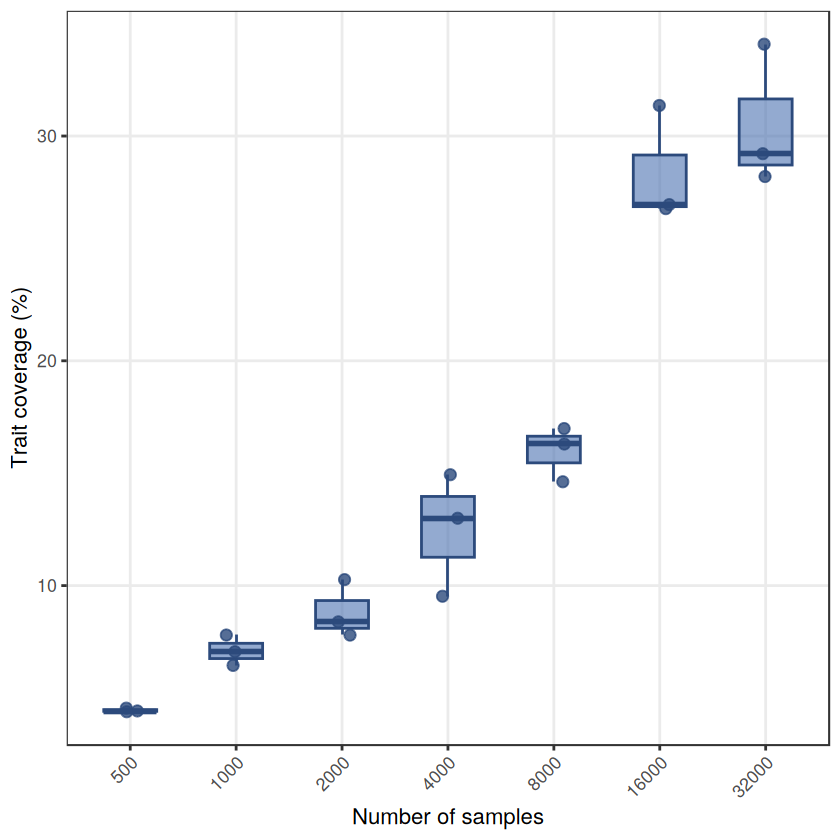

In [9]:
p <- ggplot(results_df,
            aes(x = sample_size, y = trait_coverage * 100)) +
    geom_boxplot(fill = "#4C72B0", color = "#2c4a7c",
                 alpha = 0.6, outlier.shape = NA, width = 0.5) +
    geom_jitter(color = "#2c4a7c", width = 0.1, size = 2.5, alpha = 0.8) +
    labs(
        x       = "Number of samples",
        y       = "Trait coverage (%)"
    ) +
    theme_bw(base_size = 13) +
    theme(
        axis.text.x      = element_text(angle = 45, hjust = 1),
        panel.grid.minor = element_blank()
    )

print(p)

## Summary Table

In [10]:
results_df %>%
    group_by(sample_size) %>%
    summarise(
        median_sig_traits = median(sig_traits),
        median_coverage   = round(median(trait_coverage) * 100, 2),
        min_coverage      = round(min(trait_coverage) * 100, 2),
        max_coverage      = round(max(trait_coverage) * 100, 2),
        n                 = n(),
        .groups           = "drop"
    ) %>%
    arrange(sample_size)

sample_size,median_sig_traits,median_coverage,min_coverage,max_coverage,n
<fct>,<int>,<dbl>,<dbl>,<dbl>,<int>
500,179,4.42,4.40,4.54,3
1000,286,7.06,6.45,7.80,3
2000,340,8.40,7.80,10.27,3
4000,526,12.99,9.53,14.94,3
8000,660,16.30,14.62,16.99,3
16000,1091,26.94,26.77,31.37,3
32000,1183,29.22,28.20,34.08,3
